# Stress Testing — Code Companion

This notebook computes all statistics documented in the accompanying reference files:

- **Methodology:** `documentation/Stress_methodology.md` — scenario construction, formulas, and interpretation
- **Results:** `documentation/Stress_results.md` — all numerical outputs, findings, and risk actions

**Sections**
1. Setup
2. Scenario Library
3. Portfolio Stress Results
4. Instrument-Level Attribution
5. Asset Class Decomposition
6. Stress P&L vs Statistical Risk
7. Scenario Correlation

## 1. Setup

In [26]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print('Working directory:', repo_root)

Working directory: /home/martin/python/risk-assessment


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

from data_loader import (
    clean_prices,
    load_positions,
    load_prices,
    load_scenarios,
)
from risk_metrics import (
    compute_cvar_historical,
    compute_var_historical,
)
from stress import (
    apply_scenarios,
    instrument_stress_attribution,
    subclass_stress_breakdown,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option('display.float_format', '{:.6f}'.format)


In [28]:
positions  = load_positions()
PORTFOLIO_NAV = positions["market_value_chf"].sum()
scenarios  = load_scenarios()
prices_raw = load_prices()
prices_clean = clean_prices(prices_raw)

prices_wide = (
    prices_clean
    .pivot(index='date', columns='instrument_id', values='price')
    .sort_index()
)
returns = prices_wide.pct_change().dropna(how='all')

weights = positions.set_index('instrument_id')['weight']
common  = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

print(f"Portfolio NAV:           CHF {PORTFOLIO_NAV/1e6:.0f} M")
print(f"Instruments in portfolio: {len(positions)}")
print(f"Scenarios available:      {scenarios['scenario_id'].nunique()}")
print(f"Return series:            {len(port_returns)} days  "
      f"({port_returns.index.min().date()} → {port_returns.index.max().date()})")

Portfolio NAV:           CHF 500 M
Instruments in portfolio: 18
Scenarios available:      3
Return series:            252 days  (2025-04-01 → 2026-03-18)


## 2. Scenario Library
*Methodology: `Stress_methodology.md` section 3 · Results: `Stress_results.md` section 1*

In [29]:
descs = (
    scenarios[['scenario_id', 'scenario_name', 'description']]
    .drop_duplicates('scenario_id')
    .set_index('scenario_id')
)
for _, row in descs.iterrows():
    print(row['scenario_name'])
    print(f"  {row['description']}", end="\n\n")

shock_pivot = (
    scenarios
    .pivot(index='instrument_id', columns='scenario_name', values='shock_return')
    .merge(positions[['instrument_id', 'sub_class', 'weight']], on='instrument_id')
    .sort_values(['sub_class', 'instrument_id'])
    .set_index('instrument_id')
)
scenario_cols = [c for c in shock_pivot.columns if c not in ('sub_class', 'weight')]

display(
    shock_pivot.style
    .format({
        **{col: '{:+.1%}' for col in scenario_cols},
        'weight': '{:.1%}',
    })
    .background_gradient(cmap='RdYlGn', subset=pd.Index(scenario_cols), vmin=-0.25, vmax=0.25)
    .set_caption('Scenario shock returns by instrument (green = gain, red = loss)')
)

# Verify EU Sovereign description against shock data:
# description claims CHF_GOVT rallies, EUR_GOVT sells off — confirm from data.
eu_sov = "European Sovereign Debt Stress"
sub_shocks = (
    scenarios[scenarios['scenario_name'] == eu_sov]
    .merge(positions[['instrument_id', 'sub_class']], on='instrument_id')
    .groupby('sub_class')['shock_return']
    .mean()
    .sort_index()
)
print(f"\n{eu_sov} — mean shock by sub-class:")
for sc, val in sub_shocks.items():
    direction = 'rallies (+)' if val > 0 else 'sells off (-)'
    print(f"  {sc:<15} {val:>+7.1%}  {direction}")


SNB Emergency Rate Hike (+100bp)
  The SNB raises rates by 100bp unexpectedly to defend the CHF amid inflation concerns. Bond prices fall via duration; equities decline with financials and insurance hit hardest.

European Sovereign Debt Stress
  A French fiscal crisis triggers spread widening across European sovereigns. Flight to quality into Swiss government bonds. Corporate credit and European equities sell off sharply.

Global Equity Market Crash
  A sudden global equity sell-off of ~20%, led by technology stocks. Flight to quality supports government bonds. Corporate credit spreads widen moderately.



,European Sovereign Debt Stress,Global Equity Market Crash,SNB Emergency Rate Hike (+100bp),sub_class,weight
instrument_id,,,,,
NESN_CORP,-3.0%,-2.0%,-4.6%,CHF_CORP,6.0%
NOVN_CORP,-3.5%,-2.5%,-6.1%,CHF_CORP,5.0%
UBSG_CORP,-5.0%,-4.0%,-6.3%,CHF_CORP,4.0%
CHGOV_10Y,+4.0%,+5.0%,-8.7%,CHF_GOVT,10.0%
CHGOV_2Y,+0.5%,+1.0%,-1.9%,CHF_GOVT,15.0%
CHGOV_5Y,+2.0%,+3.0%,-4.6%,CHF_GOVT,12.0%
ALV_GR,-12.0%,-20.0%,-8.0%,EUR_EQUITY,2.0%
ASML_NA,-8.0%,-25.0%,-7.0%,EUR_EQUITY,2.5%
SAN_FP,-10.0%,-15.0%,-3.0%,EUR_EQUITY,3.0%



European Sovereign Debt Stress — mean shock by sub-class:
  CHF_CORP          -3.8%  sells off (-)
  CHF_GOVT          +2.2%  rallies (+)
  EUR_EQUITY       -10.0%  sells off (-)
  EUR_GOVT          -4.5%  sells off (-)
  SWISS_EQUITY      -5.2%  sells off (-)


## 3. Portfolio Stress Results
*Methodology: `Stress_methodology.md` section 4 · Results: `Stress_results.md` section 2*

Scenario                                   Return   P&L (CHF M)
--------------------------------------------------------------
Global Equity Market Crash                 -5.09%  CHF    -25.4 M
SNB Emergency Rate Hike (+100bp)           -4.91%  CHF    -24.5 M
European Sovereign Debt Stress             -2.49%  CHF    -12.4 M


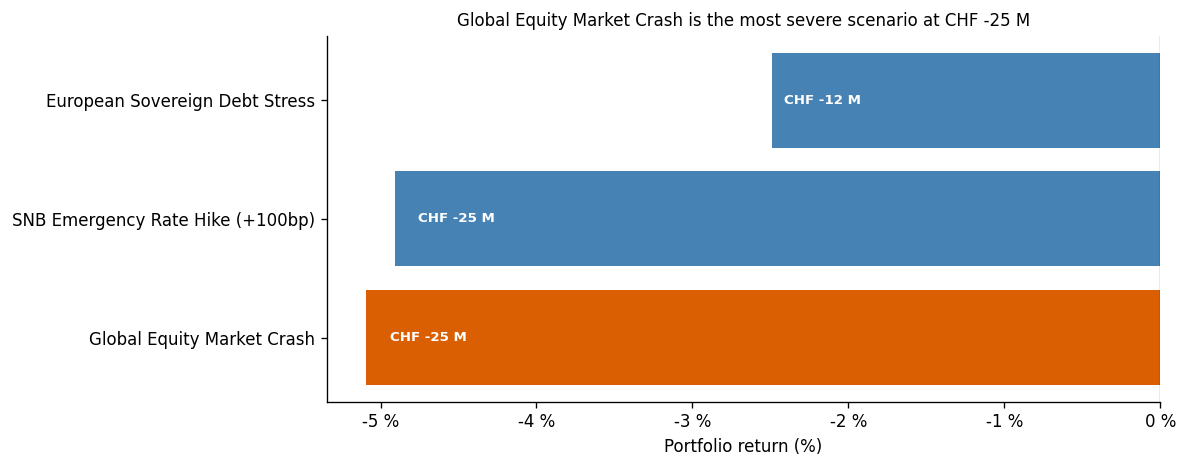

In [30]:
results = apply_scenarios(positions, scenarios).sort_values('portfolio_return')
results['pnl_chf_m'] = results['pnl_chf'] / 1e6

print(f"{'Scenario':<40} {'Return':>8}  {'P&L (CHF M)':>12}")
print('-' * 62)
for _, row in results.iterrows():
    print(f"{row['scenario_name']:<40} {row['portfolio_return']:>8.2%}  "
          f"CHF {row['pnl_chf_m']:>+8.1f} M")

worst_idx = results.index[0]
colors = ['#d95f02' if i == worst_idx else 'steelblue' for i in results.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(results['scenario_name'], results['portfolio_return'] * 100,
        color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.7)

# Direct labels inside bars
for _, row in results.iterrows():
    x_val = row['portfolio_return'] * 100
    ax.text(x_val * 0.97, row['scenario_name'],
            f"CHF {row['pnl_chf_m']:+.0f} M",
            ha='left', va='center', fontsize=8, color='white', fontweight='bold')

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f} %"))
ax.set_xlabel('Portfolio return (%)')

worst_name = results.loc[worst_idx, 'scenario_name']
worst_pnl  = results.loc[worst_idx, 'pnl_chf_m']
ax.set_title(
    f"{worst_name} is the most severe scenario at CHF {worst_pnl:+.0f} M",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 4. Instrument-Level Attribution
*Methodology: `Stress_methodology.md` section 4 · Results: `Stress_results.md` section 3*

In [31]:
attr = instrument_stress_attribution(positions, scenarios)
attr['contribution_bps'] = attr['weighted_return'] * 10_000

contrib_pivot = (
    attr
    .pivot(index='instrument_id', columns='scenario_name', values='contribution_bps')
    .merge(positions[['instrument_id', 'sub_class', 'weight']], on='instrument_id')
    .sort_values(['sub_class', 'instrument_id'])
    .set_index('instrument_id')
)
scenario_cols = [c for c in contrib_pivot.columns if c not in ('sub_class', 'weight')]

_contrib_vals = contrib_pivot[scenario_cols].to_numpy()
vmin_cal = float(np.nanmin(_contrib_vals)) * 1.3
vmax_cal = float(np.nanmax(_contrib_vals)) * 1.3

display(
    contrib_pivot.style
    .format({
        **{c: '{:+.1f} bps' for c in scenario_cols},
        'weight': '{:.1%}',
    })
    .background_gradient(cmap='RdYlGn', subset=pd.Index(scenario_cols), vmin=vmin_cal, vmax=vmax_cal)
    .set_caption(
        f'Instrument contribution per scenario (bps) '
        f'— colour scale: {vmin_cal:.0f} to +{vmax_cal:.0f} bps'
    )
)

worst_scenario = results.iloc[0]['scenario_name']
worst_attr = (
    attr[attr['scenario_name'] == worst_scenario]
    .assign(contribution_bps=lambda d: d['weighted_return'] * 10_000)
    .sort_values('contribution_bps')
)

print(f"\nWorst scenario: {worst_scenario}")
print(f"{'Instrument':<15} {'Sub-class':<15} {'Shock':>8}  {'Contribution':>14}  {'P&L (CHF M)':>12}")
print('-' * 70)
for _, row in worst_attr.iterrows():
    print(f"{row['instrument_id']:<15} {row['sub_class']:<15} "
          f"{row['shock_return']:>8.1%}  "
          f"{row['contribution_bps']:>+11.1f} bps  "
          f"CHF {row['pnl_chf']/1e6:>+7.1f} M")

,European Sovereign Debt Stress,Global Equity Market Crash,SNB Emergency Rate Hike (+100bp),sub_class,weight
instrument_id,,,,,
NESN_CORP,-18.0 bps,-12.0 bps,-27.6 bps,CHF_CORP,6.0%
NOVN_CORP,-17.5 bps,-12.5 bps,-30.5 bps,CHF_CORP,5.0%
UBSG_CORP,-20.0 bps,-16.0 bps,-25.2 bps,CHF_CORP,4.0%
CHGOV_10Y,+40.0 bps,+50.0 bps,-87.0 bps,CHF_GOVT,10.0%
CHGOV_2Y,+7.5 bps,+15.0 bps,-28.5 bps,CHF_GOVT,15.0%
CHGOV_5Y,+24.0 bps,+36.0 bps,-55.2 bps,CHF_GOVT,12.0%
ALV_GR,-24.0 bps,-40.0 bps,-16.0 bps,EUR_EQUITY,2.0%
ASML_NA,-20.0 bps,-62.5 bps,-17.5 bps,EUR_EQUITY,2.5%
SAN_FP,-30.0 bps,-45.0 bps,-9.0 bps,EUR_EQUITY,3.0%



Worst scenario: Global Equity Market Crash
Instrument      Sub-class          Shock    Contribution   P&L (CHF M)
----------------------------------------------------------------------
NOVN            SWISS_EQUITY      -15.0%        -82.5 bps  CHF    -4.1 M
UBSG            SWISS_EQUITY      -22.0%        -77.0 bps  CHF    -3.9 M
ROG             SWISS_EQUITY      -15.0%        -75.0 bps  CHF    -3.8 M
NESN            SWISS_EQUITY      -12.0%        -72.0 bps  CHF    -3.6 M
ASML_NA         EUR_EQUITY        -25.0%        -62.5 bps  CHF    -3.1 M
ABBN            SWISS_EQUITY      -18.0%        -54.0 bps  CHF    -2.7 M
SIE_GR          EUR_EQUITY        -18.0%        -45.0 bps  CHF    -2.2 M
SAN_FP          EUR_EQUITY        -15.0%        -45.0 bps  CHF    -2.2 M
SREN            SWISS_EQUITY      -20.0%        -40.0 bps  CHF    -2.0 M
ALV_GR          EUR_EQUITY        -20.0%        -40.0 bps  CHF    -2.0 M
UBSG_CORP       CHF_CORP           -4.0%        -16.0 bps  CHF    -0.8 M
NOVN_CORP  

## 5. Asset Class Decomposition
*Methodology: `Stress_methodology.md` section 4 · Results: `Stress_results.md` section 4*

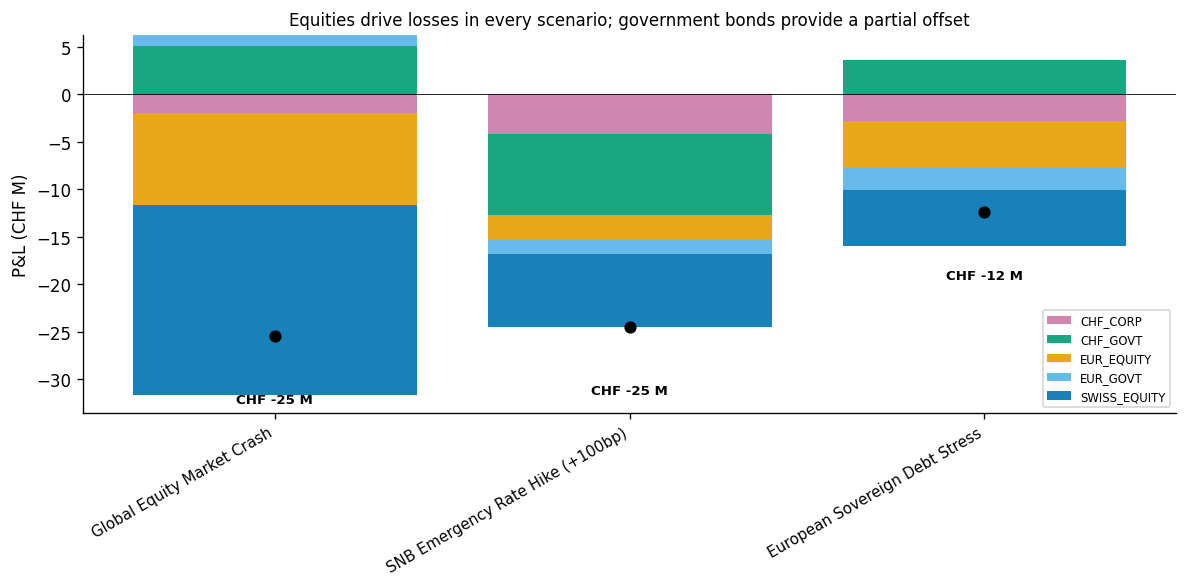


Sub-class         Alloc (CHF M)  Global Equity Market  SNB Emergency Rate H  European Sovereign D
--------------------------------------------------------------------------------------------------
CHF_CORP                   75 M      -2.0 M ( -2.7%)      -4.2 M ( -5.6%)      -2.8 M ( -3.7%)
CHF_GOVT                  185 M      +5.0 M ( +2.7%)      -8.5 M ( -4.6%)      +3.6 M ( +1.9%)
EUR_EQUITY                 50 M      -9.6 M (-19.2%)      -2.6 M ( -5.2%)      -5.0 M ( -9.9%)
EUR_GOVT                   65 M      +1.2 M ( +1.8%)      -1.5 M ( -2.4%)      -2.4 M ( -3.7%)
SWISS_EQUITY              125 M     -20.0 M (-16.0%)      -7.7 M ( -6.1%)      -5.9 M ( -4.7%)
--------------------------------------------------------------------------------------------------
TOTAL                     500 M     -25.4 M ( -5.1%)     -24.5 M ( -4.9%)     -12.5 M ( -2.5%)


In [32]:
sub_df = subclass_stress_breakdown(positions, scenarios)
sub_df['pnl_chf_m'] = sub_df['pnl_chf'] / 1e6

scenario_order = results['scenario_name'].tolist()  # worst first
sub_classes = sorted(sub_df['sub_class'].unique())

# Sleeve exposure: sum of weights per sub-class × NAV
sleeve_chf_m = positions.groupby('sub_class')['weight'].sum() * PORTFOLIO_NAV / 1e6

# Okabe-Ito colorblind-safe palette
SUB_COLOURS = {
    'SWISS_EQUITY': '#0072B2',
    'EUR_EQUITY':   '#E69F00',
    'CHF_CORP':     '#CC79A7',
    'CHF_GOVT':     '#009E73',
    'EUR_GOVT':     '#56B4E9',
}

fig, ax = plt.subplots(figsize=(10, 5))
bottoms_pos = np.zeros(len(scenario_order))
bottoms_neg = np.zeros(len(scenario_order))
x = np.arange(len(scenario_order))

for sc in sub_classes:
    vals = np.array([
        float(sub_df[
            (sub_df['scenario_name'] == sn) & (sub_df['sub_class'] == sc)]['pnl_chf_m'].sum())
        for sn in scenario_order
    ])
    pos_vals = np.where(vals >= 0, vals, 0)
    neg_vals = np.where(vals <  0, vals, 0)
    ax.bar(x, pos_vals, bottom=bottoms_pos,
           color=SUB_COLOURS.get(sc, 'grey'), label=sc, edgecolor='none', alpha=0.9)
    ax.bar(x, neg_vals, bottom=bottoms_neg,
           color=SUB_COLOURS.get(sc, 'grey'), edgecolor='none', alpha=0.9)
    bottoms_pos += pos_vals
    bottoms_neg += neg_vals

totals = [sub_df[sub_df['scenario_name'] == sn]['pnl_chf_m'].sum() for sn in scenario_order]
ax.scatter(x, totals, color='black', zorder=5, s=40)
for xi, tot in zip(x, totals, strict=True):
    ax.text(float(xi), tot - 6, f"CHF {tot:+.0f} M",
            ha='center', va='top', fontsize=8, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(scenario_order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('P&L (CHF M)')
ax.legend(fontsize=7, loc='lower right')
ax.set_title(
    'Equities drive losses in every scenario; government bonds provide a partial offset',
    fontsize=10,
)
plt.tight_layout()
plt.show()

# Summary table — includes sleeve allocation so P&L can be read as a % of each sleeve
col_w = 22
hdr_alloc = f"{'Alloc (CHF M)':>14}"
print(f"\n{'Sub-class':<16} {hdr_alloc}", end='')
for sn in scenario_order:
    print(f"  {sn[:col_w - 2]:>{col_w - 2}}", end='')
print()
print('-' * (16 + 16 + col_w * len(scenario_order)))
for sc in sub_classes:
    alloc = float(sleeve_chf_m.get(sc, 0.0))
    print(f"{sc:<16} {alloc:>12.0f} M", end='')
    for sn in scenario_order:
        pnl = float(sub_df[
            (sub_df['scenario_name'] == sn) & (sub_df['sub_class'] == sc)]['pnl_chf_m'].sum())
        pct = pnl / alloc * 100 if alloc > 0 else float('nan')
        print(f"  {pnl:>+8.1f} M ({pct:>+5.1f}%)", end='')
    print()
print('-' * (16 + 16 + col_w * len(scenario_order)))
total_alloc = PORTFOLIO_NAV / 1e6
print(f"{'TOTAL':<16} {total_alloc:>12.0f} M", end='')
for sn in scenario_order:
    pnl = float(sub_df[sub_df['scenario_name'] == sn]['pnl_chf_m'].sum())
    pct = pnl / total_alloc * 100
    print(f"  {pnl:>+8.1f} M ({pct:>+5.1f}%)", end='')
print()

## 6. Stress P&L vs Statistical Risk
*Methodology: `Stress_methodology.md` section 5 · Results: `Stress_results.md` section 5*

Statistical risk benchmarks (full-sample)
  VaR 99% 1-day  (historical):  2.0153%   CHF 10.1 M
  ES  99% 1-day  (historical):  2.3921%   CHF 12.0 M
  VaR 99% 10-day (√10 scaled):  6.3730%   CHF 31.9 M  (*)

Scenario                                    Loss   x VaR 1d   x ES 1d   x VaR 10d (*)
------------------------------------------------------------------------------------
Global Equity Market Crash                 5.09%       2.5x      2.1x            0.8x
SNB Emergency Rate Hike (+100bp)           4.91%       2.4x      2.1x            0.8x
European Sovereign Debt Stress             2.49%       1.2x      1.0x            0.4x


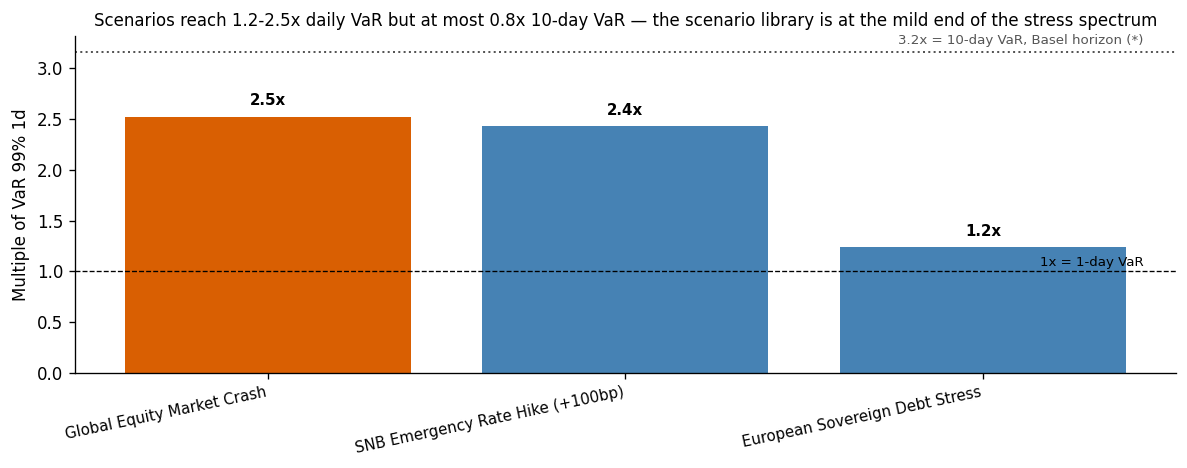


(*) The 10-day VaR reference uses √10 scaling, which assumes i.i.d. returns.
    Clustering in Sep–Nov 2025 inflates this figure (see VaR backtesting methodology).
    All scenarios sitting below the dotted line may partly reflect √10 overestimation,
    not only mild scenario calibration.

Scenario-to-limit distance  (L = -10% of NAV = CHF -50 M)
  k_s = L / r_s;  k_s ≤ 1 means the scenario already breaches

Scenario                                     r_s     k_s  Headroom
------------------------------------------------------------------------
Global Equity Market Crash                -5.09%    1.96×  1.96× to limit
SNB Emergency Rate Hike (+100bp)          -4.91%    2.04×  2.04× to limit
European Sovereign Debt Stress            -2.49%    4.02×  4.02× to limit


In [33]:
var_1d_hist  = compute_var_historical(port_returns, confidence=0.99)
es_1d_hist   = compute_cvar_historical(port_returns, confidence=0.99)
var_10d      = var_1d_hist * (10 ** 0.5)

print('Statistical risk benchmarks (full-sample)')
print(f"  VaR 99% 1-day  (historical):  {var_1d_hist:.4%}   "
      f"CHF {var_1d_hist*PORTFOLIO_NAV/1e6:.1f} M")
print(f"  ES  99% 1-day  (historical):  {es_1d_hist:.4%}   "
      f"CHF {es_1d_hist*PORTFOLIO_NAV/1e6:.1f} M")
print(f"  VaR 99% 10-day (√10 scaled):  {var_10d:.4%}   CHF {var_10d*PORTFOLIO_NAV/1e6:.1f} M  (*)")
print()

var_multiples = results.copy()
var_multiples['loss_pct']    = -var_multiples['portfolio_return']
var_multiples['var1d_mult']  = var_multiples['loss_pct'] / var_1d_hist
var_multiples['var10d_mult'] = var_multiples['loss_pct'] / var_10d
var_multiples['es1d_mult']   = var_multiples['loss_pct'] / es_1d_hist

print(f"{'Scenario':<40} {'Loss':>7}  {'x VaR 1d':>9}  {'x ES 1d':>8}  {'x VaR 10d (*)':>14}")
print('-' * 84)
for _, row in var_multiples.iterrows():
    print(f"{row['scenario_name']:<40} {row['loss_pct']:>7.2%}  "
          f"{row['var1d_mult']:>8.1f}x  "
          f"{row['es1d_mult']:>7.1f}x  "
          f"{row['var10d_mult']:>13.1f}x")

# Chart: x VaR 1d bars with the 10-day VaR horizon as reference
# The 10-day VaR reference line (√10 ≈ 3.16x) is marked (*) because
# the i.i.d. assumption it requires is contradicted by the sample.
var10d_line = var_10d / var_1d_hist  # ≈ √10

worst_bar_idx = var_multiples.index[0]
colors = ['#d95f02' if i == worst_bar_idx else 'steelblue' for i in var_multiples.index]
x = np.arange(len(var_multiples))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, var_multiples['var1d_mult'], color=colors, edgecolor='none')

ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.text(len(x) - 0.55, 1.05, '1x = 1-day VaR', ha='right', fontsize=8, color='black')

ax.axhline(var10d_line, color='#555555', linewidth=1.2, linestyle=':')
ax.text(len(x) - 0.55, var10d_line + 0.08,
        f"{var10d_line:.1f}x = 10-day VaR, Basel horizon (*)",
        ha='right', fontsize=8, color='#555555')

# Direct labels on bars
for xi, (_, row) in zip(x, var_multiples.iterrows(), strict=True):
    ax.text(float(xi), row['var1d_mult'] + 0.08, f"{row['var1d_mult']:.1f}x",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(var_multiples['scenario_name'], rotation=12, ha='right', fontsize=9)
ax.set_ylabel('Multiple of VaR 99% 1d')

min_mult = var_multiples['var1d_mult'].min()
max_mult = var_multiples['var1d_mult'].max()
max_10d  = var_multiples['var10d_mult'].max()
ax.set_title(
    f"Scenarios reach {min_mult:.1f}-{max_mult:.1f}x daily VaR but at most {max_10d:.1f}x "
    "10-day VaR — the scenario library is at the mild end of the stress spectrum",
    fontsize=10,
)
plt.tight_layout()
plt.show()

print()
print("(*) The 10-day VaR reference uses √10 scaling, which assumes i.i.d. returns.")
print("    Clustering in Sep–Nov 2025 inflates this figure (see VaR backtesting methodology).")
print("    All scenarios sitting below the dotted line may partly reflect √10 overestimation,")
print("    not only mild scenario calibration.")

# Scenario-to-limit distance — methodology section 6.1
# L and r_s both negative for loss scenarios; k_s = L / r_s is positive.
# k_s ≤ 1 means the unscaled scenario already breaches the limit.
LOSS_LIMIT_PCT = -0.10  # −10% of NAV = −CHF 50 M on CHF 500 M
print()
print(f"Scenario-to-limit distance  "
      f"(L = {LOSS_LIMIT_PCT:.0%} of NAV = CHF {LOSS_LIMIT_PCT * PORTFOLIO_NAV / 1e6:.0f} M)")
print(f"  k_s = L / r_s;  k_s ≤ 1 means the scenario already breaches")
print()
print(f"{'Scenario':<40} {'r_s':>7}  {'k_s':>6}  {'Headroom'}")
print('-' * 72)
for _, row in var_multiples.sort_values('portfolio_return').iterrows():
    r_s = row['portfolio_return']
    k_s = LOSS_LIMIT_PCT / r_s
    headroom = 'BREACH' if k_s <= 1 else f'{k_s:.2f}× to limit'
    print(f"{row['scenario_name']:<40} {r_s:>7.2%}  {k_s:>6.2f}×  {headroom}")


## 7. Scenario Correlation & Risk Factor Coverage
*Methodology: `Stress_methodology.md` section 7 · Results: `Stress_results.md` section 7*

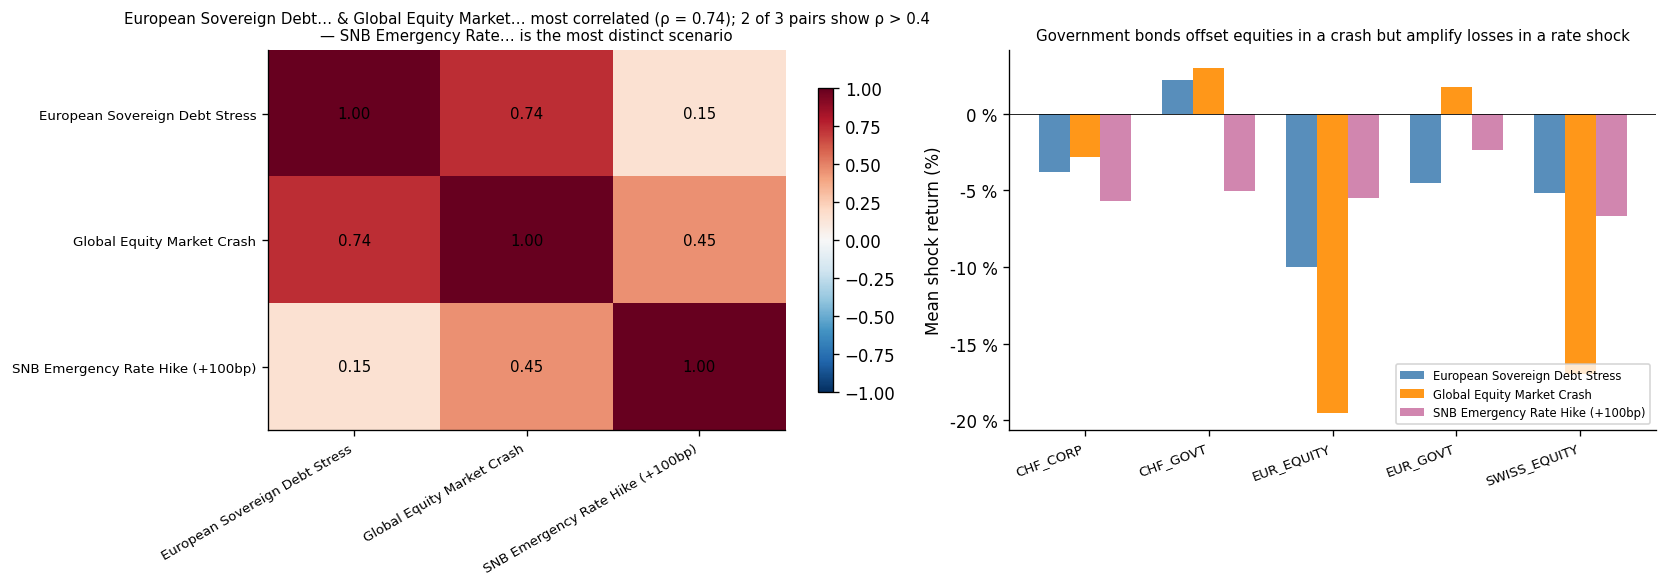

Pairwise scenario correlations:
  European Sovereign Debt Stress vs Global Equity Market Crash: 0.7376
  European Sovereign Debt Stress vs SNB Emergency Rate Hike (+100bp): 0.1522
  Global Equity Market Crash vs SNB Emergency Rate Hike (+100bp): 0.4538


In [34]:
SCEN_COLOURS = ['steelblue', 'darkorange', '#CC79A7']

shock_matrix = scenarios.pivot(
    index='instrument_id', columns='scenario_name', values='shock_return'
).dropna()
corr = shock_matrix.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correlation heatmap — RdBu_r is colorblind-safe (no red/green)
ax = axes[0]
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        # Black text throughout: max |ρ| in this matrix is 0.74 — medium-intensity
        # background — white-on-coloured gives poor contrast at that level.
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha='center', va='center', fontsize=9, color='black')

# Identify the highest-correlation pair and the most distinct scenario
corr_upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
sorted_pairs = corr_upper.stack().sort_values(ascending=False)
max_pair = sorted_pairs.index[0]
max_rho  = float(sorted_pairs.iloc[0])
n_moderate = int((corr_upper.stack() > 0.4).sum())
# Most distinct = scenario whose maximum |ρ| with any other is smallest
max_abs_per = corr.abs().where(~np.eye(len(corr), dtype=bool)).max()
distinct_sc = str(max_abs_per.idxmin())

def _abbrev(name: str, n_words: int = 3) -> str:
    words = name.split()
    return ' '.join(words[:n_words]) + ('…' if len(words) > n_words else '')

sn_a = _abbrev(max_pair[0])
sn_b = _abbrev(max_pair[1])
sn_d = _abbrev(distinct_sc)
ax.set_title(
    f"{sn_a} & {sn_b} most correlated (ρ = {max_rho:.2f}); "
    f"{n_moderate} of 3 pairs show ρ > 0.4\n"
    f"— {sn_d} is the most distinct scenario",
    fontsize=9,
)

# Right: average sub-class shock per scenario
ax2 = axes[1]
shock_w_sub = shock_matrix.merge(
    positions[['instrument_id', 'sub_class']].set_index('instrument_id'),
    left_index=True, right_index=True,
)
sub_mean = shock_w_sub.groupby('sub_class')[shock_matrix.columns.tolist()].mean()
x = np.arange(len(sub_mean))
w = 0.25
for i, (sn, col) in enumerate(zip(shock_matrix.columns, SCEN_COLOURS, strict=True)):
    ax2.bar(x + (i - 1) * w, sub_mean[sn] * 100, w,
            color=col, label=sn, edgecolor='none', alpha=0.9)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(sub_mean.index, rotation=20, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f} %"))
ax2.set_ylabel('Mean shock return (%)')
ax2.set_title('Government bonds offset equities in a crash but amplify losses in a rate shock', fontsize=9)
ax2.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

print('Pairwise scenario correlations:')
for i, sn_i in enumerate(corr.columns):
    for j, sn_j in enumerate(corr.columns):
        if j > i:
            print(f"  {sn_i} vs {sn_j}: {corr.loc[sn_i, sn_j]:.4f}")